# Evaluación 2 - Modelado Predictivo de Ingresos Recurrentes (MRR)

**Integrantes:**   
Alexis Arévalo  
Correo: alexis.arevalo2301@alumnos.ubiobio.cl

Gabriel Ascencio  
Correo: gabriel.ascencio2301@alumnos.ubiobio.cl

Alonso Barra  
Correo: alonso.barra2301@alumnos.ubiobio.cl

Cristobal Bravo  
Correo: cristobal.bravo2201@alumnos.ubiobio.cl

**Asignatura:** Inteligencia Artificial

---

## Objetivo

Construir un modelo predictivo capaz de estimar el Ingreso Mensual Recurrente del próximo trimestre (`mrr_proximo_trimestre`) de los clientes B2B de **SaaSFlow**, para anticipar fugas de ingresos y asignar estratégicamente los recursos de *Customer Success*.

**Modelo utilizado:** Regresión Lineal.

**Estructura del notebook:**
- **Fase 1:** Diagnóstico y calidad de datos (EDA).
- **Fase 2:** Limpieza, ingeniería de características, codificación y escalado.
- **Fase 3:** Construcción del modelo (Pipeline + división train/test).
- **Fase 4:** Evaluación e interpretación de métricas (R² y MAE).

Todo el preprocesamiento que aprende de los datos (imputación y escalado) se encapsula en un `Pipeline` de scikit-learn para evitar la fuga de datos (*data leakage*).

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

from sklearn.impute import SimpleImputer

# Fase 1: Diagnóstico y Calidad de Datos

In [2]:
url = "https://raw.githubusercontent.com/ale-are/IA-Ev2/refs/heads/main/E2-Regresion/clientes_mrr_dataset.csv"

df = pd.read_csv(url)

df.head()

,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,706.16
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,555.95
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,755.53
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,364.94
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1611.93


In [3]:
df.shape

(30000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB


In [5]:
df.tail()

,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
29995,CLI-29996,2021-02-19 03:43:09.566318877,Tecnologia,Pequeña,2.0,9.207036,6.0,Anual,1463.827746,Si,390.15
29996,CLI-29997,2025-09-12 04:36:43.753458432,Salud,Pequeña,1.0,8.709533,10.0,Mensual,2287.654797,Si,477.66
29997,CLI-29998,2022-10-16 22:03:47.287576248,Retail,Grande,4.0,47.125552,6.0,Mensual,3132.574236,Si,1025.74
29998,CLI-29999,2022-01-24 03:06:37.813260440,Tecnologia,Mediana,2.0,52.007538,2.0,Anual,4743.422344,Si,901.41
29999,CLI-30000,2025-02-01 11:22:26.324877488,Finanzas,Pequeña,1.0,112.746705,9.0,Mensual,3229.870789,No,672.15


In [6]:
nulos = pd.DataFrame({
    "Cantidad": df.isnull().sum(),
    "Porcentaje": df.isnull().mean()*100
})

nulos

,Cantidad,Porcentaje
id_cliente,0,0.000000
fecha_registro,0,0.000000
sector_empresa,0,0.000000
tamano_empresa,0,0.000000
tickets_soporte,2464,8.213333
promedio_sesiones_mes,1545,5.150000
satisfaccion_nps,3597,11.990000
duracion_contrato,0,0.000000
gasto_mkt_asociado,0,0.000000
pago_puntual,0,0.000000


In [7]:
df.dtypes

,0
id_cliente,object
fecha_registro,object
sector_empresa,object
tamano_empresa,object
tickets_soporte,float64
promedio_sesiones_mes,float64
satisfaccion_nps,float64
duracion_contrato,object
gasto_mkt_asociado,float64
pago_puntual,object


### Revisión de tipos de datos

Se observa que `fecha_registro` está almacenada como tipo `object`, por lo que
deberá transformarse posteriormente a formato `datetime` para realizar la
ingeniería de características.

Las variables `sector_empresa`, `tamano_empresa`, `duracion_contrato` y
`pago_puntual` también se encuentran como tipo `object`, lo cual es esperable
por tratarse de variables categóricas. Estas deberán codificarse antes de
entrenar el modelo.

Las variables `tickets_soporte` y `satisfaccion_nps` aparecen como `float64`
debido a la presencia de valores nulos, aunque conceptualmente corresponden
a variables numéricas discretas.

## Detección de duplicados e inconsistencias

Se revisan registros repetidos y valores imposibles según las reglas del negocio (NPS fuera de 1–10, conteos o montos negativos, fechas futuras).

In [8]:
print("Registros duplicados:", df.duplicated().sum())
print("Duplicados ignorando id_cliente:", df.drop(columns="id_cliente").duplicated().sum())
print("IDs de cliente repetidos:", df["id_cliente"].duplicated().sum())

Registros duplicados: 0
Duplicados ignorando id_cliente: 0
IDs de cliente repetidos: 0


In [9]:
fechas = pd.to_datetime(df["fecha_registro"])

inconsistentes = df[
    (df["satisfaccion_nps"] < 1) | (df["satisfaccion_nps"] > 10) |
    (df["tickets_soporte"] < 0) |
    (df["promedio_sesiones_mes"] < 0) |
    (df["gasto_mkt_asociado"] < 0) |
    (df["mrr_proximo_trimestre"] <= 0)
]
print("Registros inconsistentes:", len(inconsistentes))
print("Rango de fechas de registro:", fechas.min().date(), "a", fechas.max().date())

Registros inconsistentes: 0
Rango de fechas de registro: 2021-01-01 a 2025-12-31


No existen registros duplicados ni valores imposibles. Todas las fechas de registro están entre 2021 y 2025, por lo que ninguna es posterior a la fecha de referencia que se usará para calcular la antigüedad.

## Análisis estadístico inicial

Se revisan medidas de tendencia central y dispersión
para identificar rangos, variabilidad y posibles valores extremos.

In [10]:
df.describe()

,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,gasto_mkt_asociado,mrr_proximo_trimestre
count,27536.000000,28455.000000,26403.000000,30000.000000,30000.000000
mean,3.005121,50.130595,5.913911,2551.090539,710.926286
std,1.734139,45.058935,2.312062,1416.112727,337.688948
min,0.000000,5.001555,1.000000,100.355894,50.000000
25%,2.000000,18.086442,4.000000,1330.525002,458.985000
50%,3.000000,36.230789,6.000000,2541.073850,642.595000
75%,4.000000,67.451126,8.000000,3785.665164,896.705000
max,12.000000,430.701397,10.000000,4999.953843,3200.040000


In [11]:
numericas_eda = [
    "tickets_soporte",
    "promedio_sesiones_mes",
    "satisfaccion_nps",
    "gasto_mkt_asociado",
    "mrr_proximo_trimestre"
]

resumen_numericas = pd.DataFrame({
    "Media": df[numericas_eda].mean(),
    "Mediana": df[numericas_eda].median(),
    "Desviación estándar": df[numericas_eda].std(),
    "Asimetría": df[numericas_eda].skew()
})

resumen_numericas.round(3)

,Media,Mediana,Desviación estándar,Asimetría
tickets_soporte,3.005,3.000,1.734,0.569
promedio_sesiones_mes,50.131,36.231,45.059,1.972
satisfaccion_nps,5.914,6.000,2.312,-0.417
gasto_mkt_asociado,2551.091,2541.074,1416.113,0.004
mrr_proximo_trimestre,710.926,642.595,337.689,1.055


### Análisis de asimetría

`promedio_sesiones_mes` presenta una asimetría positiva elevada (aproximadamente
1.97), observándose además una diferencia importante entre su media y mediana.
Por esta razón, la mediana resulta apropiada para imputar sus valores faltantes.

`tickets_soporte` presenta una asimetría positiva moderada y corresponde a una
variable discreta, mientras que `satisfaccion_nps` corresponde a una escala
discreta de 1 a 10. Para ambas se utilizará el valor más frecuente (moda) como
estrategia de imputación.

In [12]:
variables_numericas = df.select_dtypes(
    include=np.number
)

variables_numericas.columns

Index(['tickets_soporte', 'promedio_sesiones_mes', 'satisfaccion_nps',
       'gasto_mkt_asociado', 'mrr_proximo_trimestre'],
      dtype='object')

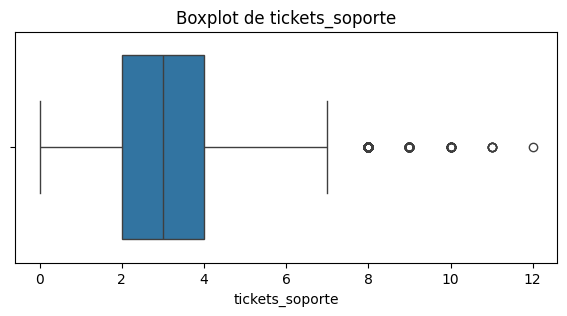

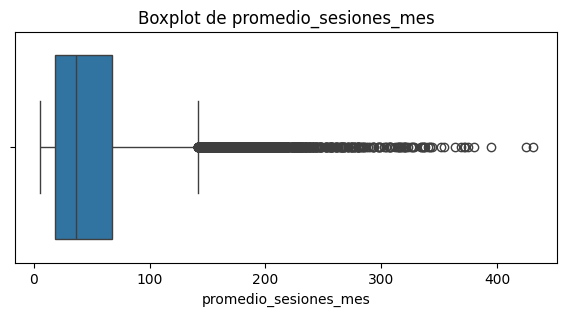

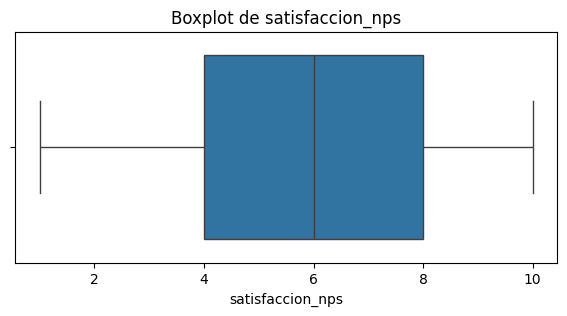

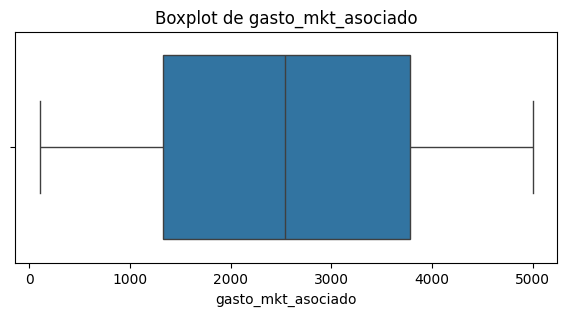

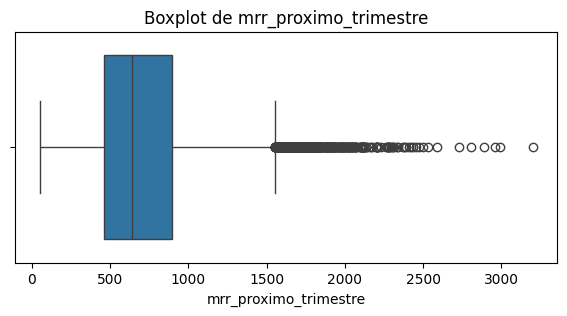

In [13]:
for columna in numericas_eda:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df[columna]
    )

    plt.title(
        f"Boxplot de {columna}"
    )

    plt.show()

In [14]:
# Cuantificación de atípicos con el criterio del rango intercuartílico (IQR)
atipicos = {}
for col in numericas_eda:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    atipicos[col] = {"Cantidad": n, "Porcentaje": round(n / len(df) * 100, 2)}

pd.DataFrame(atipicos).T

,Cantidad,Porcentaje
tickets_soporte,328.0,1.09
promedio_sesiones_mes,1367.0,4.56
satisfaccion_nps,0.0,0.00
gasto_mkt_asociado,0.0,0.00
mrr_proximo_trimestre,607.0,2.02


### Análisis de valores atípicos

- **`promedio_sesiones_mes`** es la variable con más atípicos (≈ 4.6%) y la más sesgada (asimetría ≈ 1.97): pocos clientes usan la plataforma de forma muy intensiva.
- **`tickets_soporte`** tiene ≈ 1.1% de atípicos (clientes con muchos tickets).
- **`satisfaccion_nps`** y **`gasto_mkt_asociado`** no presentan atípicos.
- **`mrr_proximo_trimestre`** (variable objetivo) tiene ≈ 2% de atípicos, correspondientes a clientes de alto valor.

**Decisión:** los valores atípicos se conservan, ya que no corresponden a
valores imposibles ni inconsistentes con el dominio de las variables. Además,
pueden representar comportamientos de clientes con niveles de actividad o MRR
superiores al resto de la muestra. La variable objetivo no se modifica.

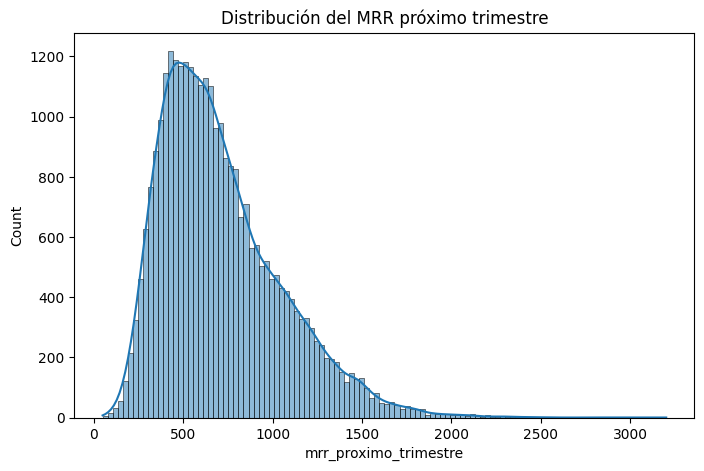

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["mrr_proximo_trimestre"],
    kde=True
)

plt.title(
    "Distribución del MRR próximo trimestre"
)

plt.show()

La distribución del MRR presenta asimetría positiva (≈ 1.06): la mayoría de los clientes se concentra en valores medios y una minoría de alto valor forma una cola hacia la derecha.

In [16]:
variables_categoricas = [
    "sector_empresa",
    "tamano_empresa",
    "duracion_contrato",
    "pago_puntual"
]

for columna in variables_categoricas:
    print(f"\n{columna}:")
    print(df[columna].unique())


sector_empresa:
['Finanzas' 'Tecnologia' 'Educacion' 'Salud' 'Retail']

tamano_empresa:
['Mediana' 'Pequeña' 'Grande']

duracion_contrato:
['Mensual' '2 Años' 'Anual']

pago_puntual:
['Si' 'No']


## Conclusiones del análisis exploratorio

- **Nulos:** `satisfaccion_nps` (11.99%), `tickets_soporte` (8.21%) y `promedio_sesiones_mes` (5.15%). El resto de las variables está completo.
- **Tipos inconsistentes:** `fecha_registro` está como texto y debe transformarse; `sector_empresa`, `tamano_empresa`, `duracion_contrato` y `pago_puntual` son categóricas sin codificar.
- **Sesgos y atípicos:** `promedio_sesiones_mes` es fuertemente asimétrica
  y concentra la mayor cantidad de valores atípicos. Estos valores se conservan,
  ya que no corresponden a valores imposibles ni inconsistentes con el dominio
  de las variables.
- **Calidad:** no hay duplicados ni valores imposibles.

Estos hallazgos definen las estrategias de limpieza y transformación de la Fase 2.

# Fase 2: Limpieza y Preprocesamiento

Separación de variables predictoras (X) y variable objetivo (y).

In [17]:
X = df.drop(
    "mrr_proximo_trimestre",
    axis=1
)

y = df["mrr_proximo_trimestre"]

In [18]:
X = X.drop(
    "id_cliente",
    axis=1
)

X.head()

,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual
0,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si
1,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No
2,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si
3,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No
4,2021-09-26 05:21:16.482549416,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si


## Ingeniería de características: Antigüedad del cliente

La fecha de registro se transforma en una variable numérica que representa
la antigüedad del cliente en días, calculada respecto de una fecha de
referencia fija.

In [19]:
# Convertir fecha a formato datetime

X["fecha_registro"] = pd.to_datetime(
    X["fecha_registro"]
)

fecha_referencia = pd.Timestamp("2026-09-29")

X["antiguedad_dias"] = (
    fecha_referencia - X["fecha_registro"]
).dt.days

X = X.drop(
    "fecha_registro",
    axis=1
)

X.head()

,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,antiguedad_dias
0,Finanzas,Mediana,3.0,34.350838,7.0,Mensual,3932.341944,Si,379
1,Tecnologia,Mediana,NaN,28.685569,8.0,Mensual,2547.833298,No,959
2,Tecnologia,Pequeña,5.0,50.027033,7.0,2 Años,3203.232664,Si,2063
3,Educacion,Pequeña,0.0,NaN,9.0,Anual,603.209270,No,1866
4,Educacion,Grande,3.0,NaN,8.0,Anual,864.788600,Si,1828


Se utiliza una fecha de referencia fija para garantizar que la variable
`antiguedad_dias` produzca los mismos valores cada vez que se ejecute
el notebook.

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sector_empresa         30000 non-null  object 
 1   tamano_empresa         30000 non-null  object 
 2   tickets_soporte        27536 non-null  float64
 3   promedio_sesiones_mes  28455 non-null  float64
 4   satisfaccion_nps       26403 non-null  float64
 5   duracion_contrato      30000 non-null  object 
 6   gasto_mkt_asociado     30000 non-null  float64
 7   pago_puntual           30000 non-null  object 
 8   antiguedad_dias        30000 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 2.1+ MB


## Definición de variables para el preprocesamiento

Se separan las variables según su naturaleza para aplicar
transformaciones específicas antes del entrenamiento.

In [21]:
# Variable con distribución sesgada: imputación por mediana
numericas_mediana = [
    "promedio_sesiones_mes"
]

# Variables numéricas discretas: imputación por moda
numericas_moda = [
    "tickets_soporte",
    "satisfaccion_nps"
]

# Variables continuas sin valores nulos
numericas_continuas = [
    "gasto_mkt_asociado",
    "antiguedad_dias"
]

# Variable categórica nominal
nominales = [
    "sector_empresa"
]

# Variable categórica ordinal
ordinales = [
    "tamano_empresa"
]

# Variables categóricas transformadas mediante mapeo
mapeadas = [
    "duracion_contrato",
    "pago_puntual"
]

In [22]:
X.columns

Index(['sector_empresa', 'tamano_empresa', 'tickets_soporte',
       'promedio_sesiones_mes', 'satisfaccion_nps', 'duracion_contrato',
       'gasto_mkt_asociado', 'pago_puntual', 'antiguedad_dias'],
      dtype='object')

## Escalado de variables

Se aplica `StandardScaler` (media 0, desviación estándar 1) a las variables numéricas continuas y discretas, para que variables con magnitudes muy distintas (por ejemplo, `gasto_mkt_asociado` en miles y `satisfaccion_nps` entre 1 y 10) sean comparables.

Se evaluó también `RobustScaler` y el resultado fue idéntico: en una regresión lineal el escalado no cambia las predicciones, solo la escala en que se expresan los coeficientes.

In [23]:
pipeline_mediana = Pipeline([
    (
        "imputacion",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

pipeline_moda = Pipeline([
    (
        "imputacion",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

pipeline_continuas = Pipeline([
    (
        "scaler",
        StandardScaler()
    )
])

In [24]:
pipeline_nominal = Pipeline([

    (
        "imputacion",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
       OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    )
    )
])

In [25]:
pipeline_ordinal = Pipeline([

    (
        "imputacion",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "ordinal",
        OrdinalEncoder(
            categories=[
                [
                    "Pequeña",
                    "Mediana",
                    "Grande"
                ]
            ]
        )
    )
])

## Mapeo de variables categóricas

- `pago_puntual` es binaria: **Si → 1**, **No → 0**.
- `duracion_contrato` posee un orden natural de duración:
  **Mensual → 0, Anual → 1, 2 Años → 2**.

Estos mapeos corresponden a reglas definidas por el significado de las
categorías y no requieren aprender estadísticas del conjunto de datos.

Este mapeo es una regla fija que se aplica fila por fila y **no aprende ningún valor de los datos**, por lo que puede realizarse antes de dividir el conjunto sin generar fuga de datos.

In [26]:
X["pago_puntual"] = X["pago_puntual"].map({
    "Si":1,
    "No":0
})


X["duracion_contrato"] = X["duracion_contrato"].map({
    "Mensual":0,
    "Anual":1,
    "2 Años":2
})

In [27]:
preprocesador = ColumnTransformer(
    transformers=[

        (
            "sesiones_mediana",
            pipeline_mediana,
            numericas_mediana
        ),

        (
            "numericas_moda",
            pipeline_moda,
            numericas_moda
        ),

        (
            "continuas",
            pipeline_continuas,
            numericas_continuas
        ),

        (
            "nominales",
            pipeline_nominal,
            nominales
        ),

        (
            "ordinales",
            pipeline_ordinal,
            ordinales
        ),

        (
            "mapeadas",
            "passthrough",
            mapeadas
        )
    ]
)

# Fase 3: Construcción del Modelo

In [28]:
modelo = Pipeline([
    ("preprocesamiento", preprocesador),
    ("regresion", LinearRegression())
])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
modelo.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('sesiones_mediana',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['promedio_sesiones_mes']),
                                                 ('numericas_moda',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tickets_soporte',
                                                   'sa...
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sector_empresa']),
                                                 ('ordinales',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Pequeña',
                                                                                               'Mediana',
                                                                                               'Grande']]))]),
                                                  ['tamano_empresa']),
                                                 ('mapeadas', 'passthrough',
                                                  ['duracion_contrato',
                                                   'pago_puntual'])])),
                ('regresion', LinearRegression())])

### Prevención de fuga de datos

- La **mediana**, la **moda** y los parámetros del **escalado** se calculan **solo con `X_train`** al ejecutar `modelo.fit(X_train, y_train)`.
- Al predecir sobre `X_test`, el Pipeline aplica esos mismos valores aprendidos, sin recalcularlos con datos de prueba.
- Las transformaciones realizadas antes del split (antigüedad y mapeo) usan reglas fijas por fila, sin estadísticas del conjunto.

# Fase 4: Evaluación e Interpretación de Métricas

In [31]:
y_pred = modelo.predict(
    X_test
)

In [32]:
r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)


print("Coeficiente R²:", r2)
print("MAE:", mae)

Coeficiente R²: 0.9239982335051639
MAE: 68.31734703744539


## Evaluación del modelo

El modelo de Regresión Lineal fue evaluado utilizando el conjunto de prueba
mediante las métricas R² y MAE.

### Coeficiente de Determinación (R²)

El modelo obtuvo un R² de aproximadamente **0.924**.

Esto indica que el modelo explica cerca del **92.4 % de la variabilidad**
del ingreso mensual recurrente del próximo trimestre a partir de las
variables predictoras consideradas.

In [33]:
y_pred_train = modelo.predict(X_train)

print(f"{'R² en train':<15}: {r2_score(y_train, y_pred_train):.4f}")
print(f"{'R² en test':<15}: {r2:.4f}")

R² en train    : 0.9188
R² en test     : 0.9240


El R² de entrenamiento y el de prueba son muy similares, por lo que
**no se observa evidencia importante de sobreajuste**. Esto indica que el
modelo mantiene un desempeño similar en datos no utilizados durante el
entrenamiento.

In [34]:
mrr_promedio = y_test.mean()

print(f"MRR promedio en test       : {mrr_promedio:.2f} USD")
print(f"MAE                        : {mae:.2f} USD")
print(f"MAE / MRR promedio         : {mae / mrr_promedio:.1%}")

MRR promedio en test       : 708.31 USD
MAE                        : 68.32 USD
MAE / MRR promedio         : 9.6%


### Error Absoluto Medio (MAE)

El modelo obtuvo un MAE de aproximadamente **68.32 USD**: en promedio, la proyección del MRR de cada cliente se desvía unos **68 dólares** del valor real.

**Contexto financiero para SaaSFlow:**
- El MAE equivale aproximadamente al 9.6% del MRR promedio del conjunto de prueba.
- Este nivel de precisión es adecuado para **priorizar cuentas** y detectar clientes con riesgo de caída de ingresos, pero no para facturación exacta.
- Como el error se mide en valor absoluto, las sobreestimaciones y
  subestimaciones no se compensan: aproximadamente **68 USD corresponde
  al error absoluto promedio por cliente** que el equipo debe considerar
  al utilizar las predicciones.

### Síntesis de negocio

- **R² ≈ 0.924:** el modelo explica aproximadamente el **92.4% de la
  variabilidad observada del MRR** en el conjunto de prueba.
- **MAE ≈ 68 USD:** el modelo presenta una diferencia absoluta promedio
  de aproximadamente **68 USD por cliente** entre el MRR predicho y el real.

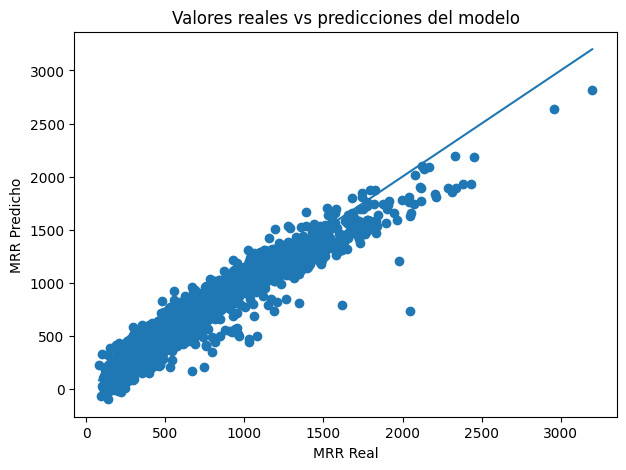

In [35]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("MRR Real")
plt.ylabel("MRR Predicho")

plt.title(
    "Valores reales vs predicciones del modelo"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [36]:
coeficientes = modelo.named_steps["regresion"].coef_

coeficientes

array([ 1.75092788e+02, -2.94328186e+01,  4.79415272e+01,  3.29728369e+01,
       -2.76193699e-01,  6.74504316e-01,  2.45726786e+00, -1.93419528e-01,
        1.71946830e-01,  3.23359723e+02,  1.28444472e+02,  2.04336746e+02])

In [37]:
nombres = (
    modelo
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

importancia = pd.DataFrame({
    "Variable": nombres,
    "Coeficiente": coeficientes
})

importancia.sort_values(
    "Coeficiente",
    ascending=False
)

,Variable,Coeficiente
9,ordinales__tamano_empresa,323.359723
11,mapeadas__pago_puntual,204.336746
0,sesiones_mediana__promedio_sesiones_mes,175.092788
10,mapeadas__duracion_contrato,128.444472
2,numericas_moda__satisfaccion_nps,47.941527
3,continuas__gasto_mkt_asociado,32.972837
6,nominales__sector_empresa_Retail,2.457268
5,nominales__sector_empresa_Finanzas,0.674504
8,nominales__sector_empresa_Tecnologia,0.171947
7,nominales__sector_empresa_Salud,-0.193420


## Efecto de cada variable en unidades de negocio

Como las variables numéricas fueron estandarizadas, sus coeficientes están expresados por desviación estándar. Para interpretarlos en dólares, se dividen por la escala aprendida por cada `StandardScaler`:

In [38]:
ct = modelo.named_steps["preprocesamiento"]

# Desviación estándar aprendida por cada escalador (solo con X_train)
escalas = {}
for nombre, columnas in [("sesiones_mediana", numericas_mediana),
                         ("numericas_moda", numericas_moda),
                         ("continuas", numericas_continuas)]:
    for col, s in zip(columnas, ct.named_transformers_[nombre].named_steps["scaler"].scale_):
        escalas[col] = s

# Unidad de referencia para interpretar cada variable
unidades = {
    "promedio_sesiones_mes": (1, "1 sesión mensual adicional"),
    "tickets_soporte": (1, "1 ticket de soporte adicional"),
    "satisfaccion_nps": (1, "1 punto más de NPS"),
    "gasto_mkt_asociado": (1000, "1.000 USD más en marketing"),
    "antiguedad_dias": (365, "1 año más de antigüedad"),
    "tamano_empresa": (1, "subir 1 nivel de tamaño (Pequeña → Mediana → Grande)"),
    "duracion_contrato": (1, "subir 1 nivel de contrato (Mensual → Anual → 2 Años)"),
    "pago_puntual": (1, "pagar puntualmente (vs. no)"),
}

filas = []
for nombre, coef in zip(nombres, coeficientes):
    var = nombre.split("__")[1]
    if var in escalas:
        factor, texto = unidades[var]
        efecto = coef / escalas[var] * factor
    elif var in unidades:
        efecto, texto = coef, unidades[var][1]
    else:  # dummies de sector
        efecto, texto = coef, f"sector {var.replace('sector_empresa_', '')} (vs. Educación)"
    filas.append({"Variable": var, "Por cada": texto, "Efecto en MRR (USD)": round(efecto, 2)})

efectos = pd.DataFrame(filas)
efectos.reindex(efectos["Efecto en MRR (USD)"].abs().sort_values(ascending=False).index)

,Variable,Por cada,Efecto en MRR (USD)
9,tamano_empresa,subir 1 nivel de tamaño (Pequeña → Mediana → G...,323.36
11,pago_puntual,pagar puntualmente (vs. no),204.34
10,duracion_contrato,subir 1 nivel de contrato (Mensual → Anual → 2...,128.44
3,gasto_mkt_asociado,1.000 USD más en marketing,23.24
2,satisfaccion_nps,1 punto más de NPS,21.83
1,tickets_soporte,1 ticket de soporte adicional,-17.65
0,promedio_sesiones_mes,1 sesión mensual adicional,3.99
6,sector_empresa_Retail,sector Retail (vs. Educación),2.46
5,sector_empresa_Finanzas,sector Finanzas (vs. Educación),0.67
4,antiguedad_dias,1 año más de antigüedad,-0.19


## Interpretación de los coeficientes

Manteniendo constantes las demás variables:

| Variable | Efecto sobre el MRR proyectado |
|---|---|
| Tamaño de empresa | ≈ **+323 USD** por cada nivel (Pequeña → Mediana → Grande) |
| Pago puntual | ≈ **+204 USD** si el cliente paga a tiempo |
| Duración del contrato | ≈ **+128 USD** por cada nivel (Mensual → Anual → 2 Años) |
| Satisfacción NPS | ≈ **+22 USD** por cada punto adicional |
| Gasto en marketing | ≈ **+23 USD** por cada 1.000 USD invertidos |
| Tickets de soporte | ≈ **−18 USD** por cada ticket adicional |
| Sesiones mensuales | ≈ **+4 USD** por cada sesión adicional |
| Sector y antigüedad | Efecto prácticamente nulo |

**Asociaciones de mayor magnitud con el MRR:** tamaño de empresa,
pago puntual y duración del contrato. El sector y la antigüedad del cliente presentan asociaciones estimadas
de baja magnitud con el MRR proyectado en este modelo.

## Recomendaciones para Customer Success

1. **Promover contratos de mayor duración**, ya que el modelo muestra una
   asociación positiva entre duración contractual y MRR proyectado.
2. **Monitorear clientes con pagos atrasados**, dado que el pago puntual se
   asocia con un mayor MRR esperado.
3. **Priorizar clientes con alta cantidad de tickets de soporte**, ya que esta
   variable presenta una asociación negativa con el MRR proyectado.
4. **Monitorear el NPS**, debido a su asociación positiva con el ingreso futuro.
5. **Utilizar las predicciones como herramienta de priorización**, considerando
   un MAE aproximado de 68 USD por cliente.

# Conclusión

El modelo de Regresión Lineal, construido con un Pipeline que integra imputación, codificación y escalado sin fuga de datos, permite estimar el MRR del próximo trimestre de los clientes B2B de SaaSFlow.

En el conjunto de prueba obtuvo un **R² de 0.924**, explicando el 92.4% de la variabilidad del MRR futuro, y un **MAE de 68.32 USD**, equivalente a ≈ 9.6% del MRR promedio por cliente. El R² de entrenamiento y el de prueba son muy similares, por lo que
**no se observa evidencia importante de sobreajuste**.

Las asociaciones de mayor magnitud observadas en el modelo corresponden al
**tamaño de la empresa**, el **pago puntual** y la **duración del contrato**,
seguidas por la satisfacción (NPS) y el uso de la plataforma. Los
**tickets de soporte** presentan una asociación negativa con el MRR proyectado.
El sector y la antigüedad presentan efectos de menor magnitud en este modelo.

Estos resultados permiten al equipo de Customer Success identificar clientes en riesgo, priorizar la asignación de recursos y enfocar acciones de retención en contratos de mayor duración, pagos puntuales y reducción de problemas de soporte.